In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_paper/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
# %matplotlib widget

In [2]:
def load_cycling_data_ch(cell,eSOH_DIR,oCV_DIR,cyc_DIR,cyc_no):
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    cycles = np.array(dfe_0['N'].astype('int'))+1
    print(cell_no)
    cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
    N1 = cycles[cyc_no]
    print(N1)
    cyc_data_raw = cyc_data_raw1[ cyc_data_raw1['Cycle number'] == N1 ]
    cyc_data = cyc_data_raw.reset_index(drop=True)
    t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
    t_c1 = t_c1.values
    I_c1 = cyc_data['Current [mA]']/1000
    I_c1 = I_c1.values
    V_c1 = cyc_data['Voltage [V]']
    V_c1 = V_c1.values
    E_c1 = cyc_data["Expansion [mu m]"]
    E_c1 = E_c1.values
    # idx_I = np.where(np.sign(I_c1[:-1]) != np.sign(I_c1[1:]))[0] 
    # idx_I = idx_I[idx_I>50]
    idx_I = np.where(np.diff(I_c1) < -0.1)[0] 
    t = t_c1[:idx_I[0]]
    V = V_c1[:idx_I[0]]
    I = I_c1[:idx_I[0]]
    E = E_c1[:idx_I[0]]-E_c1[0]
    Q = integrate.cumtrapz(I,t, initial=0)/3600 #Ah
    
    return t,V,I,Q,E


In [3]:
spm = pybamm.lithium_ion.SPM(
    {
        "SEI": "ec reaction limited",
        "loss of active material": "stress-driven",
        "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
    }
)
# spm.print_parameter_info()
param=spm.param
parameter_values = get_parameter_values()

In [4]:
def model_error(data_time,data_current,data_voltage,parameter_values,SOC_0=0,plot_bool=False):
    # t_int = np.arange(0,data_time[-1],1)
    t_int = data_time
    f_I_int = interpolate.interp1d(data_time,-data_current)
    f_V_int = interpolate.interp1d(data_time,data_voltage)

    I_int = f_I_int(t_int)
    V_int = f_V_int(t_int)
    timescale = parameter_values.evaluate(spm.timescale)
    current_interpolant = pybamm.Interpolant(
    #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
    t_int, I_int, timescale * pybamm.t
    )

    pybamm.set_logging_level("NOTICE")
    parameter_values["Current function [A]"] = current_interpolant
    # var_pts=var_pts,
    sim = pybamm.Simulation(spm, 
                            parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver(
                                mode="safe", 
                                rtol=1e-6, 
                                atol=1e-6,
                                dt_max=10,
                                )
                            )
    # sim.solve(initial_soc = SOC_0)
    sim.solve(t_eval=t_int,initial_soc = SOC_0)
    solution = sim.solution
    t = solution["Time [s]"].entries
    V_sim = solution["Terminal voltage [V]"].entries
    I_sim = solution["Current [A]"].entries
    # Q = -solution['Discharge capacity [A.h]'].entries
    # f_I_sim = interpolate.interp1d(t,I,bounds_error=False,fill_value="extrapolate")
    # f_V_sim = interpolate.interp1d(t,V,bounds_error=False,fill_value="extrapolate")
    # I_sim = f_I_sim(t_int)
    # V_sim = f_V_sim(t_int)
    I_int = f_I_int(t)
    V_int = f_V_int(t)
    rmse = pybamm.rmse(V_int,V_sim)
    if plot_bool:
        fig, ax1 = plt.subplots(1, 1, figsize=(5, 4), sharex=True)
        ax1.plot(t, V_int, 'k')
        ax1.plot(t, V_sim, 'b--')
        ax1.text(0.7,0.2,f'RMSE: {rmse*1e3:0.1f} mV',transform=ax1.transAxes)
        # ax1.plot(t1, V1, 'r-.')
        ax1.set_ylabel("Voltage [V]")
        # ax1.set_title("Cell 01 Fresh HPPC")
        ax1.set_ylim([3,4.21])
        ax1.set_xlabel("Time [s]")
        # ax1.set_xlim([20370,20470])
        ax1.legend(['data','sim'])
        fig.tight_layout()
        plt.show()
        # fig.savefig(fig_DIR+str(int(10000*random.random()))+".png")
    return rmse

In [5]:
t_c5,V_c5,I_c5,Q_c5,E_c5 = load_cycling_data_ch(1,eSOH_DIR,oCV_DIR,cyc_DIR,1)
t_1p5c,V_1p5c,I_1p5c,Q_1p5c,E_1p5c = load_cycling_data_ch(4,eSOH_DIR,oCV_DIR,cyc_DIR,1)
t_2c,V_2c,I_2c,Q_2c,E_2c = load_cycling_data_ch(7,eSOH_DIR,oCV_DIR,cyc_DIR,1)

01
42
04
42
07
42


In [6]:
T = 273.15+25
E_r = 39570.0
R = 8.314
np.exp(E_r / R * (1 / 298.15 - 1 / T))

1.0

In [7]:
sno = 15
par_val = {}
par_val[15] = [4.0312e-08,1.8157e-07,1.0776,2.3586e-09,-4.9170e-09,-1.4406e-09]


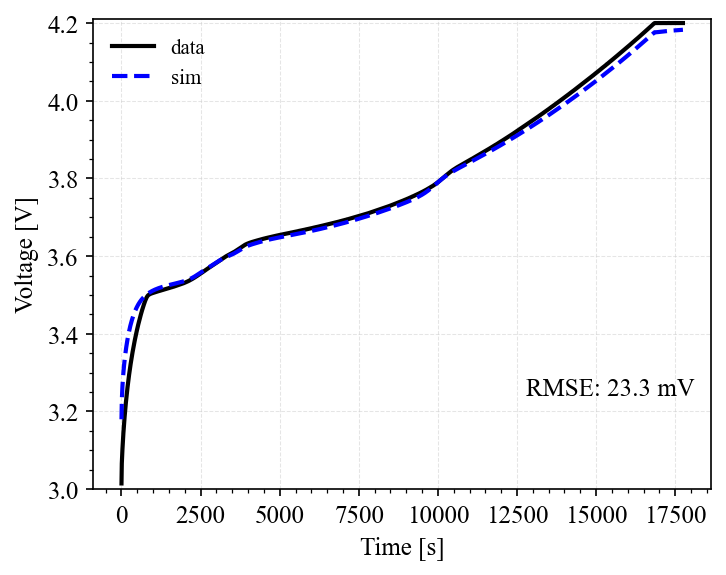

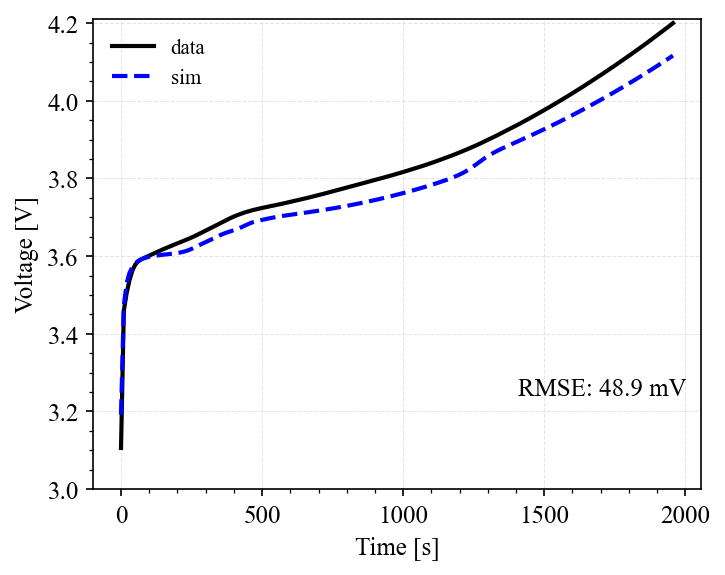

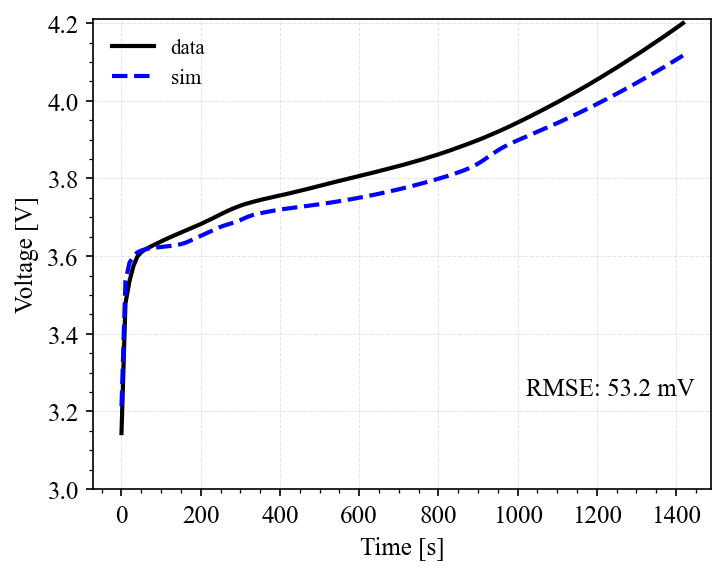

In [8]:
cell = 4
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
parameter_values = get_parameter_values()
def update_parameters(x):
    parameter_values = get_parameter_values()
    parameter_values.update(
        {
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
            "Positive electrode LAM constant proportional term [s-1]": par_val[sno][0],
            "Negative electrode LAM constant proportional term [s-1]": par_val[sno][1],
            "Positive electrode LAM constant proportional term 2 [s-1]": par_val[sno][5],
            "Negative electrode LAM constant proportional term 2 [s-1]": par_val[sno][4],
            "Positive electrode LAM constant exponential term": par_val[sno][2],
            "Negative electrode LAM constant exponential term": par_val[sno][2],
            "SEI kinetic rate constant [m.s-1]":  4.60788219e-16, #1.08494281e-16 , 
            "EC diffusivity [m2.s-1]": 4.56607447e-19,#8.30909086e-19,
            "SEI growth activation energy [J.mol-1]": 1.87422275e+04,#1.58777981e+04,
            "Lithium plating kinetic rate constant [m.s-1]": par_val[sno][3],
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "SEI resistivity [Ohm.m]": 30000.0,
            "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,
        },
        check_already_exists=False,
    )
    parameter_values.update(
        {
            "Positive electrode diffusion coefficient activation energy [J.mol-1]": x[0]*10000.0*0,
            "Negative electrode diffusion coefficient activation energy [J.mol-1]": x[1]*10000.0*0,
            "Positive electrode reference exchange-current density activation energy [J.mol-1]": x[2]*10000.0*0,
            "Negative electrode reference exchange-current density activation energy [J.mol-1]": x[3]*10000.0*0,
            
            "Positive electrode diffusion coefficient [m2.s-1]": x[0]*8e-15,# *0.93,
            "Negative electrode diffusion coefficient [m2.s-1]": x[1]*8e-14,# *30.2,
            "Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]": x[2]*3.377e-06,#*3.3,
            "Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]":	x[3]*3.183e-06,#*0.62,
            
            # "Positive electrode OCP entropic change [V.K-1]": 0,
            # "Negative electrode OCP entropic change [V.K-1]": 0,
        },
        check_already_exists=False,
    )
    return parameter_values
x = np.array([1.0,1.0,1.0,1.0])
parameter_values = update_parameters(x)
plot_bool = True
rmse1 = model_error(t_c5,I_c5,V_c5,parameter_values,SOC_0=0.005,plot_bool=plot_bool)
rmse2 = model_error(t_1p5c,I_1p5c,V_1p5c,parameter_values,SOC_0=0,plot_bool=plot_bool)
rmse3 = model_error(t_2c,I_2c,V_2c,parameter_values,SOC_0=0,plot_bool=plot_bool)

In [40]:
def prediction_error(x):
    try:
        parameter_values = update_parameters(x)
        rmse1 = model_error(t_c5,I_c5,V_c5,parameter_values,SOC_0=0.005,plot_bool=False)
        # rmse2 = model_error(t_1p5c,I_1p5c,V_1p5c,parameter_values,SOC_0=0,plot_bool=False)
        rmse3 = model_error(t_2c,I_2c,V_2c,parameter_values,SOC_0=0,plot_bool=False)
        # rmse5 = model_error(t_d1_hppc,I_d1_hppc,V_d1_hppc,parameter_values,SOC_0=1,plot_bool=False)
        out = rmse1 + rmse3 
        out = np.array([out])
        # out = rmse1 
        print(f"x={x}, norm={np.linalg.norm(out)}")
    # except pybamm.SolverError:
    except Exception as error:
        out = 5
        out = np.array([out])
        print(f"x={x}, norm={np.linalg.norm(out)}")
        print(error)
        return out
    return out
def train_model():
    timer = pybamm.Timer()
    x0 = np.array([1.0,1.0,1.0,1.0])
    lower = np.array([1e-1, 1e-1, 1e-1, 1e-1])
    upper = np.array([1e+1, 1e+1, 1e+1, 1e+1])
    dfo_opts = {
        "init.random_initial_directions":True,
        "init.run_in_parallel": True,
    }
    # soln_dfols = dfols.solve(prediction_error, x0,bounds=(lower, upper), rhoend=1e-3, user_params=dfo_opts)
    soln_dfols = dfols.solve(prediction_error, x0, rhoend=1e-3, user_params=dfo_opts)
    print(timer.time())
    return soln_dfols

In [41]:
soln_dfols = train_model()
xsol = soln_dfols.x

x=[1. 1. 1. 1.], norm=0.08592374580538097
x=[0.97551425 1.01475976 0.98141188 0.90599426], norm=0.08106381733794935
x=[0.99406488 0.91310346 1.04446749 0.97910964], norm=0.08548645132542135
x=[1.07157623 0.96704838 0.93958381 0.9881291 ], norm=0.08667472955510984
x=[0.93486886 0.96615727 0.93654129 1.02419908], norm=0.08339171128410211
x=[0.91418879 1.00985519 0.94785303 0.83465747], norm=0.07512268986812352
x=[0.67319426 0.99302316 0.81521681 0.54475067], norm=0.047143538826380726
x=[ 0.27125679  0.98171721  0.5887983  -0.00447856], norm=5.0
Events ['Minimum voltage'] are non-positive at initial conditions
x=[0.67360757 0.97955797 0.80865519 0.54543099], norm=0.04715602200514756
x=[0.66469862 0.9943382  0.81121453 0.53312844], norm=0.0462329252807464
x=[0.67459809 1.00832723 0.77945341 0.48519579], norm=0.04537999628935579
x=[0.64590589 0.99200723 0.80809748 0.444087  ], norm=0.044279297076085744
x=[0.59275402 1.00320736 0.78274579 0.44149335], norm=0.0432079611020392
x=[0.56865851 1.

In [42]:
def plot_fit(x,plot_bool = True):
    parameter_values = update_parameters(x)
    print("RMSE")
    rmse = model_error(t_c5,I_c5,V_c5,parameter_values,SOC_0=0.005,plot_bool=plot_bool)
    print(f"C/5: {rmse}")
    rmse = model_error(t_1p5c,I_1p5c,V_1p5c,parameter_values,SOC_0=0,plot_bool=plot_bool)
    print(f"1.5C: {rmse}")
    rmse = model_error(t_2c,I_2c,V_2c,parameter_values,SOC_0=0,plot_bool=plot_bool)
    print(f"2C: {rmse}")

In [43]:
xsol

array([0.41937754, 1.05800401, 0.84302748, 0.7485032 ])

In [44]:
# # Ds, i0
# xsol = [1.12912078, 1.01642996, 0.70840774, 0.2680896]
# # Activation energies
# xsol = [-0.27280449, 13.43951307,  4.70920307, -1.83341506]

RMSE


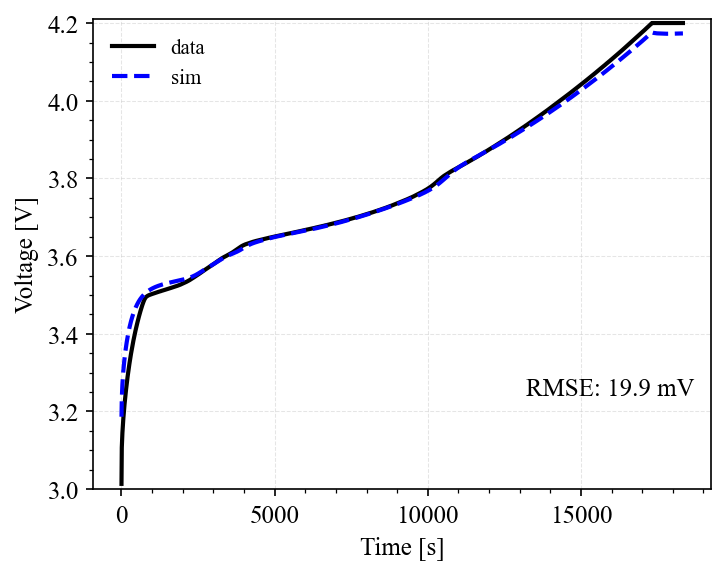

C/5: 0.01993179922340688


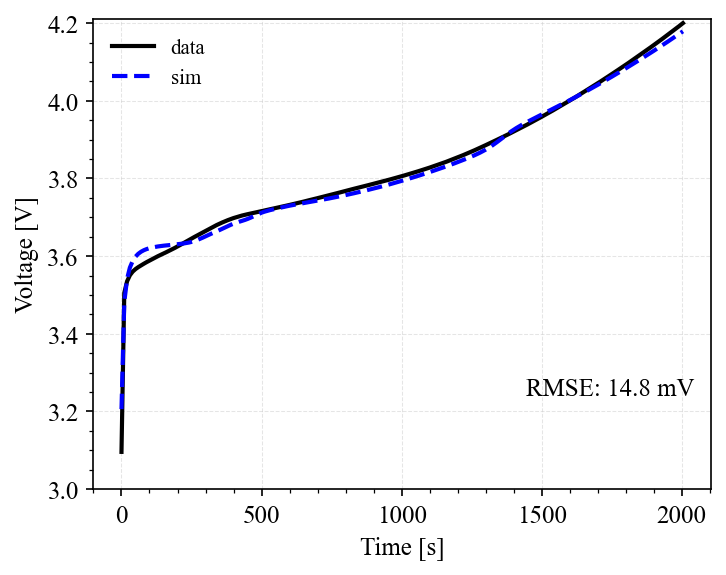

1.5C: 0.014778244585173846


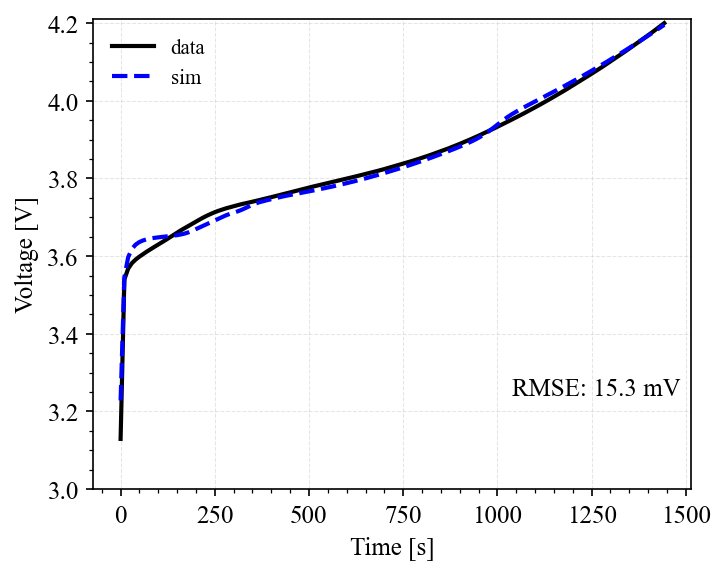

2C: 0.015323814665393514


In [45]:
plot_fit(xsol)